rows after cleaning: 740
date range: 2019-05-31 to 2020-06-30
number of states/UTs: 28
           Region       Date Frequency  unemployment_rate    employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1       Telangana 2019-05-31   Monthly               2.23  11053353.0   
2      Tamil Nadu 2019-05-31   Monthly               0.97  15844698.0   
3       Rajasthan 2019-05-31   Monthly               4.03  15226005.0   
4          Punjab 2019-05-31   Monthly               9.17   6088547.0   

   labour_participation_rate   Area  
0                      43.24  Rural  
1                      61.74  Rural  
2                      49.44  Rural  
3                      38.52  Rural  
4                      44.79  Rural  

overall unemployment rate stats:
count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: unemployment_rate, dtype: float64

highest ave

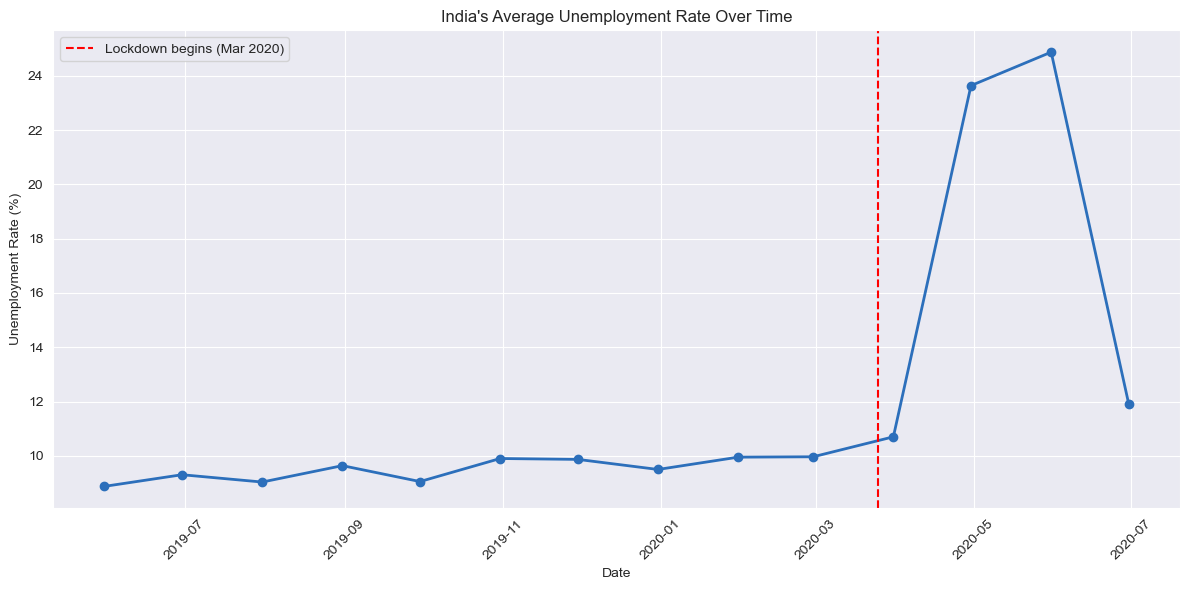

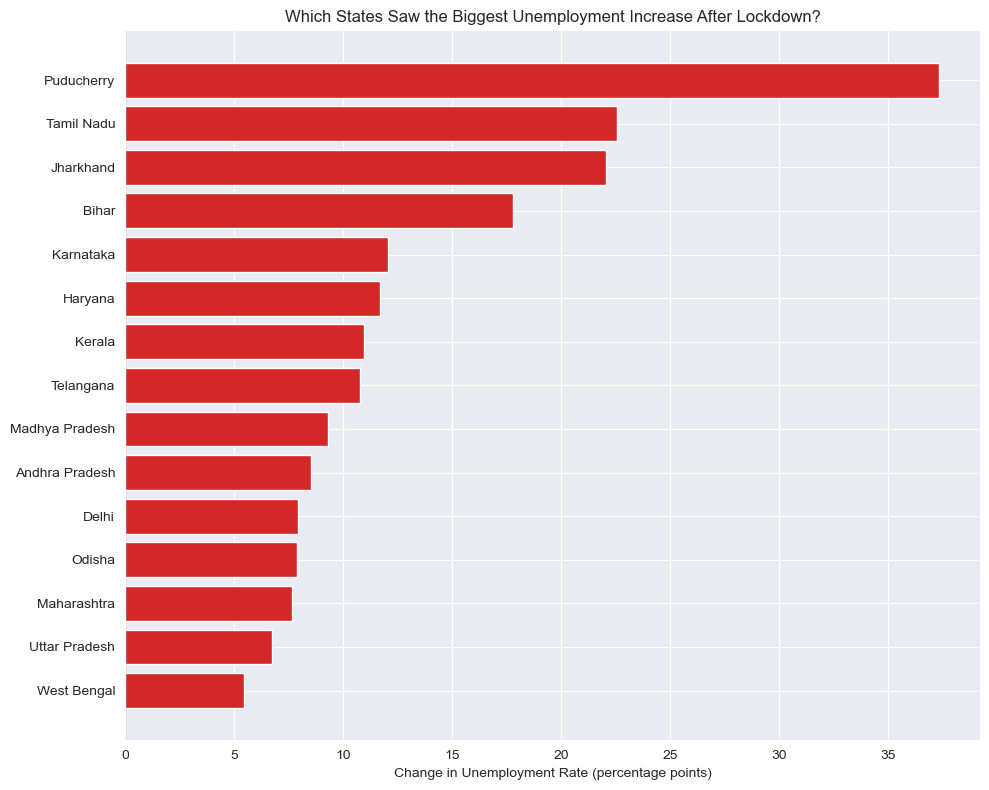

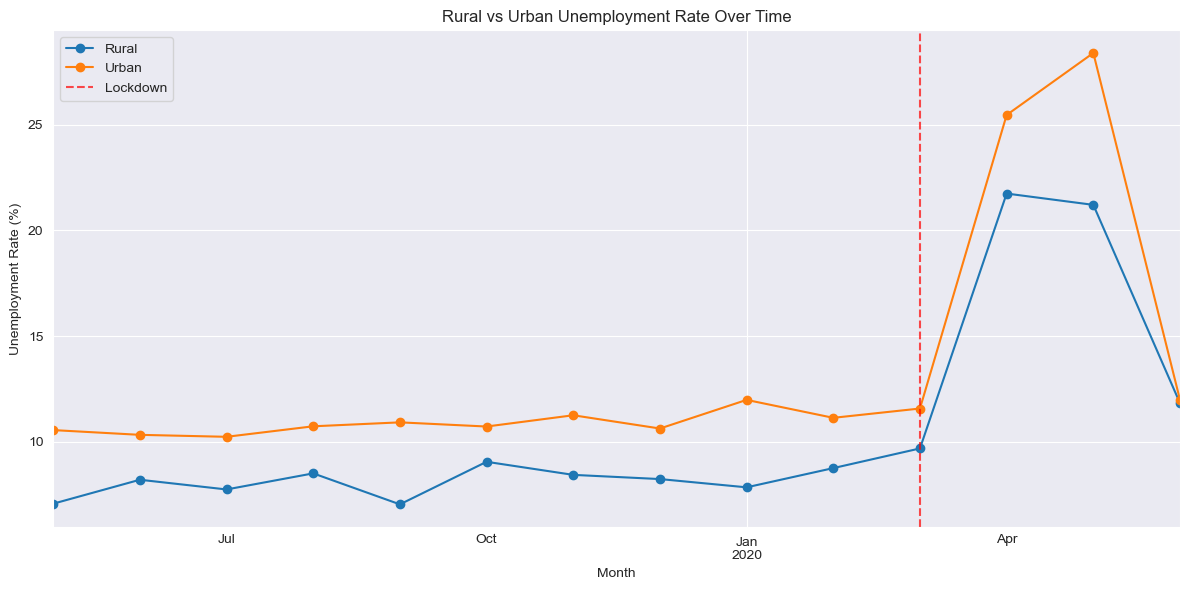

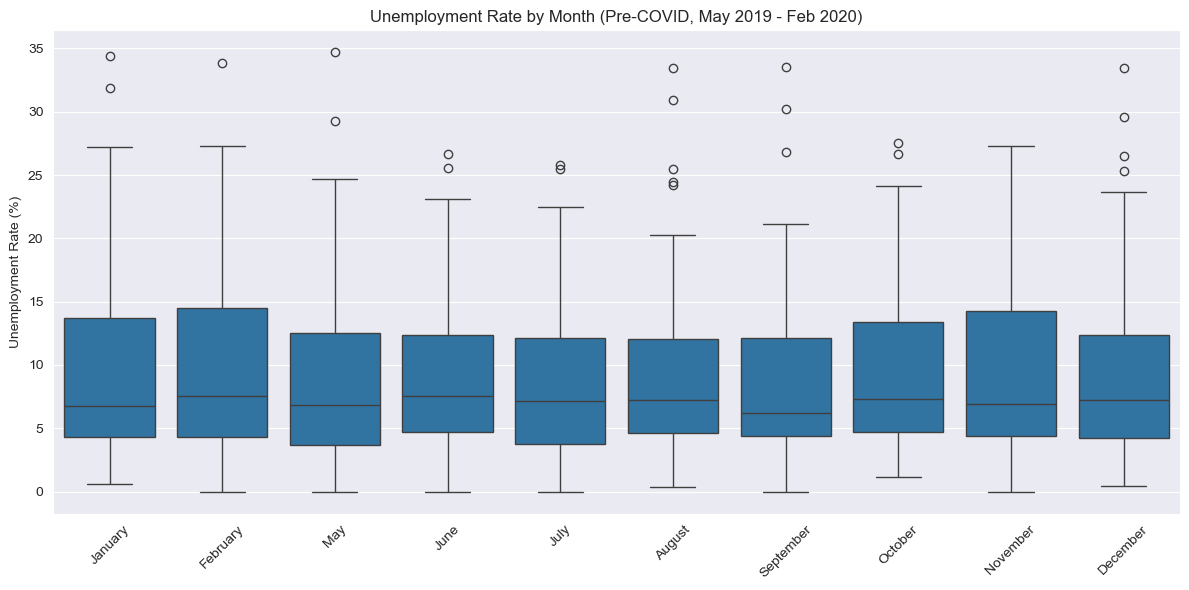

In [10]:
# Unemployment Analysis - India
# Looking at monthly unemployment rate data across Indian states from 2019-2020
# Main goal here is to see how COVID hit the job market and spot any patterns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ---- load and clean up ----
df = pd.read_csv("Unemployment in India.csv")

# the column names have leading spaces in the raw csv, gotta fix that first
df.columns = df.columns.str.strip()

# a handful of completely empty rows snuck into the file, just drop them
df = df.dropna()

# also strip whitespace out of the text columns (Region has some " Andhra Pradesh" type issues)
df["Region"] = df["Region"].str.strip()
df["Area"] = df["Area"].str.strip()

# dates are stored as strings like "31-05-2019", convert to real dates
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")

# rename the long columns so they're less annoying to type
df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "unemployment_rate",
    "Estimated Employed": "employed",
    "Estimated Labour Participation Rate (%)": "labour_participation_rate"
})

df = df.sort_values("Date").reset_index(drop=True)

print("rows after cleaning:", len(df))
print("date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("number of states/UTs:", df["Region"].nunique())
print(df.head())

# ---- quick overview stats ----
print("\noverall unemployment rate stats:")
print(df["unemployment_rate"].describe())

# national average unemployment rate per month (averaging across all states)
monthly_avg = df.groupby("Date")["unemployment_rate"].mean()
print("\nhighest average unemployment month:", monthly_avg.idxmax().strftime("%b %Y"), "->", round(monthly_avg.max(), 2), "%")
print("lowest average unemployment month:", monthly_avg.idxmin().strftime("%b %Y"), "->", round(monthly_avg.min(), 2), "%")

# ---- covid impact ----
# lockdown in India started ~25 March 2020, so split the data there
covid_start = pd.Timestamp("2020-03-25")
pre_covid = df[df["Date"] < covid_start]
post_covid = df[df["Date"] >= covid_start]

pre_avg = pre_covid["unemployment_rate"].mean()
post_avg = post_covid["unemployment_rate"].mean()

print(f"\naverage unemployment BEFORE lockdown: {pre_avg:.2f}%")
print(f"average unemployment AFTER lockdown:  {post_avg:.2f}%")
print(f"that's a jump of {post_avg - pre_avg:.2f} percentage points ({(post_avg/pre_avg - 1)*100:.0f}% relative increase)")

# which states got hit hardest during covid? compare each state's pre vs post average
state_pre = pre_covid.groupby("Region")["unemployment_rate"].mean()
state_post = post_covid.groupby("Region")["unemployment_rate"].mean()
state_change = (state_post - state_pre).dropna().sort_values(ascending=False)

print("\ntop 5 states with the biggest unemployment spike after lockdown:")
print(state_change.head(5))

# ---- rural vs urban ----
area_avg = df.groupby(["Area", df["Date"].dt.to_period("M")])["unemployment_rate"].mean().unstack(level=0)
rural_post = post_covid[post_covid["Area"] == "Rural"]["unemployment_rate"].mean()
urban_post = post_covid[post_covid["Area"] == "Urban"]["unemployment_rate"].mean()
print(f"\nduring covid - rural avg: {rural_post:.2f}%, urban avg: {urban_post:.2f}%")

# ---- seasonal / monthly pattern ----
# only really makes sense to look at this pre-covid since covid dominates the later months
df["month"] = df["Date"].dt.month_name()
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
seasonal = pre_covid.copy()
seasonal["month"] = seasonal["Date"].dt.month_name()
monthly_seasonal = seasonal.groupby("month")["unemployment_rate"].mean().reindex(month_order).dropna()
print("\npre-covid monthly averages (seasonality check):")
print(monthly_seasonal)


# 1. national trend over time with lockdown marked
fig, ax = plt.subplots()
ax.plot(monthly_avg.index, monthly_avg.values, marker="o", color="#2c6fbb", linewidth=2)
ax.axvline(covid_start, color="red", linestyle="--", label="Lockdown begins (Mar 2020)")
ax.set_title("India's Average Unemployment Rate Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()


# 2. before vs after covid, by state (top 15 most affected)
fig, ax = plt.subplots(figsize=(10, 8))
top15 = state_change.head(15)
colors = ["#d62728" if v > 0 else "#2ca02c" for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_xlabel("Change in Unemployment Rate (percentage points)")
ax.set_title("Which States Saw the Biggest Unemployment Increase After Lockdown?")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()


# 3. rural vs urban comparison over time
fig, ax = plt.subplots()
area_avg.plot(ax=ax, marker="o")
ax.axvline(pd.Period("2020-03", freq="M"), color="red", linestyle="--", alpha=0.7, label="Lockdown")
ax.set_title("Rural vs Urban Unemployment Rate Over Time")
ax.set_ylabel("Unemployment Rate (%)")
ax.set_xlabel("Month")
ax.legend()
plt.tight_layout()


# 4. seasonality boxplot (pre-covid only, so covid doesn't skew it)
fig, ax = plt.subplots()
sns.boxplot(data=seasonal, x="month", y="unemployment_rate", order=[m for m in month_order if m in seasonal["month"].unique()], ax=ax)
ax.set_title("Unemployment Rate by Month (Pre-COVID, May 2019 - Feb 2020)")
ax.set_xlabel("")
ax.set_ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

